<a href="https://colab.research.google.com/github/Onndwelam/Analystlab-africa-week2datascience/blob/main/Week_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
import numpy as np

df = pd.read_csv("HealthConnect_Appointment_Data.csv")

# Quick overview
df.head()
df.info()
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

,0
appointment_id,0
patient_id,0
gender,0
age,0
age_group,0
appointment_type,0
booking_date,0
appointment_date,0
appointment_day,0
appointment_time,0


In [64]:
import pandas as pd
df = pd.read_csv("HealthConnect_Appointment_Data.csv")
print(df.shape)
df.head()

(5000, 18)


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


In [65]:
# Check missing values
print(df.isnull().sum())

# Check class distribution
print(df["appointment_outcome"].value_counts())


appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64
appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64


In [66]:
print("Available columns:", df.columns.tolist())


Available columns: ['appointment_id', 'patient_id', 'gender', 'age', 'age_group', 'appointment_type', 'booking_date', 'appointment_date', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes', 'appointment_outcome']


In [67]:
features = [
    "age", "gender", "distance_to_clinic_km", "waiting_time_minutes",
    "previous_no_shows"   # add/remove based on actual columns
]


In [68]:
['PatientID','Age','Gender','AppointmentDate','AppointmentOutcome']


['PatientID', 'Age', 'Gender', 'AppointmentDate', 'AppointmentOutcome']

In [69]:
features = ["Age","Gender","AppointmentDate"]


In [70]:
from pathlib import Path
import hashlib
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GroupKFold,
    cross_validate
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    brier_score_loss,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibrationDisplay

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_PATH = Path("HealthConnect_Appointment_Data.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")


In [71]:
def file_sha256(path: Path) -> str:
    sha = hashlib.sha256()
    with path.open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            sha.update(block)
    return sha.hexdigest()

dataset_hash = file_sha256(DATA_PATH)

provenance = {
    "source_file": DATA_PATH.name,
    "sha256": dataset_hash,
    "note": "Original source file was read only and not overwritten."
}

with (OUTPUT_DIR / "dataset_provenance.json").open("w", encoding="utf-8") as file:
    json.dump(provenance, file, indent=2)

print(provenance)


{'source_file': 'HealthConnect_Appointment_Data.csv', 'sha256': '1f2c40ae14833b46fe6e1a353446a0e038f19ae06434b37d98545b3e28697137', 'note': 'Original source file was read only and not overwritten.'}


In [72]:
df_raw = pd.read_csv(DATA_PATH)

print("Dataset shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())

print("\nFirst five records:")
display(df_raw.head())

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))


Dataset shape: (5000, 18)

Columns:
['appointment_id', 'patient_id', 'gender', 'age', 'age_group', 'appointment_type', 'booking_date', 'appointment_date', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes', 'appointment_outcome']

First five records:


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show



Data types:


,dtype
appointment_id,object
patient_id,object
gender,object
age,int64
age_group,object
appointment_type,object
booking_date,object
appointment_date,object
appointment_day,object
appointment_time,object


In [73]:
expected_columns = [
    "appointment_id",
    "patient_id",
    "gender",
    "age",
    "age_group",
    "appointment_type",
    "booking_date",
    "appointment_date",
    "appointment_day",
    "appointment_time",
    "booking_lead_days",
    "previous_appointments",
    "previous_no_shows",
    "reminder_sent",
    "reminder_channel",
    "distance_to_clinic_km",
    "waiting_time_minutes",
    "appointment_outcome"
]

missing_columns = sorted(set(expected_columns) - set(df_raw.columns))
unexpected_columns = sorted(set(df_raw.columns) - set(expected_columns))

print("Missing required columns:", missing_columns)
print("Unexpected columns:", unexpected_columns)

if missing_columns:
    raise ValueError("Required columns are missing; stop analysis and review the file.")


Missing required columns: []
Unexpected columns: []


In [74]:
df = df_raw.copy()

text_columns = df.select_dtypes(include="object").columns
for column in text_columns:
    df[column] = df[column].astype("string").str.strip()
    df[column] = df[column].replace({"": pd.NA})

date_columns = ["booking_date", "appointment_date"]
for column in date_columns:
    df[column] = pd.to_datetime(df[column], format="%m/%d/%Y", errors="coerce")

numeric_columns_all = [
    "age",
    "booking_lead_days",
    "previous_appointments",
    "previous_no_shows",
    "distance_to_clinic_km",
    "waiting_time_minutes"
]

for column in numeric_columns_all:
    df[column] = pd.to_numeric(df[column], errors="coerce")


In [75]:
quality_report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

display(quality_report)
quality_report.to_csv(OUTPUT_DIR / "data_quality_report.csv")


,dtype,non_null,missing,missing_pct,unique
reminder_channel,string,3634,1366,27.32,3
distance_to_clinic_km,float64,4910,90,1.80,335
waiting_time_minutes,float64,4940,60,1.20,62
appointment_id,string,5000,0,0.00,5000
patient_id,string,5000,0,0.00,1696
gender,string,5000,0,0.00,3
booking_date,datetime64[ns],5000,0,0.00,593
age,int64,5000,0,0.00,63
age_group,string,5000,0,0.00,6
appointment_type,string,5000,0,0.00,4


In [76]:
exact_duplicates = df.duplicated().sum()
duplicate_appointment_ids = df["appointment_id"].duplicated(keep=False).sum()

print("Exact duplicate rows:", exact_duplicates)
print("Rows involved in duplicate appointment IDs:", duplicate_appointment_ids)

if duplicate_appointment_ids:
    display(
        df[df["appointment_id"].duplicated(keep=False)]
        .sort_values("appointment_id")
        .head(20)
    )


Exact duplicate rows: 0
Rows involved in duplicate appointment IDs: 0


In [77]:
allowed_values = {
    "gender": {"Female", "Male", "Prefer not to say"},
    "age_group": {"18-24", "25-34", "35-44", "45-54", "55-64", "65+"},
    "appointment_type": {
        "General Consultation",
        "Follow-up",
        "Specialist Consultation",
        "Diagnostic Test"
    },
    "appointment_day": {
        "Monday", "Tuesday", "Wednesday", "Thursday",
        "Friday", "Saturday", "Sunday"
    },
    "appointment_time": {"Morning", "Afternoon", "Evening"},
    "reminder_sent": {"Yes", "No"},
    "reminder_channel": {"SMS", "Email", "WhatsApp", "None"},
    "appointment_outcome": {"Attended", "No-Show", "Cancelled"}
}

category_issues = []

for column, allowed in allowed_values.items():
    observed = set(df[column].dropna().unique())
    unexpected = sorted(observed - allowed)
    category_issues.append({
        "column": column,
        "unexpected_values": unexpected,
        "unexpected_count": int(df[column].isin(unexpected).sum())
    })

category_issues = pd.DataFrame(category_issues)
display(category_issues)


,column,unexpected_values,unexpected_count
0,gender,[],0
1,age_group,[],0
2,appointment_type,[],0
3,appointment_day,[],0
4,appointment_time,[],0
5,reminder_sent,[],0
6,reminder_channel,[],0
7,appointment_outcome,[],0


In [78]:
df["calculated_lead_days"] = (
    df["appointment_date"] - df["booking_date"]
).dt.days

df["calculated_appointment_day"] = df["appointment_date"].dt.day_name()

date_after_appointment = (
    df["booking_date"].notna()
    & df["appointment_date"].notna()
    & (df["booking_date"] > df["appointment_date"])
)

lead_day_mismatch = (
    df["calculated_lead_days"].notna()
    & df["booking_lead_days"].notna()
    & (df["calculated_lead_days"] != df["booking_lead_days"])
)

weekday_mismatch = (
    df["calculated_appointment_day"].notna()
    & df["appointment_day"].notna()
    & (df["calculated_appointment_day"] != df["appointment_day"])
)

print("Booking date after appointment date:", date_after_appointment.sum())
print("Lead-day mismatches:", lead_day_mismatch.sum())
print("Appointment-day mismatches:", weekday_mismatch.sum())


Booking date after appointment date: 0
Lead-day mismatches: 0
Appointment-day mismatches: 0


In [79]:
def derive_age_group(age):
    if pd.isna(age):
        return pd.NA
    if 18 <= age <= 24:
        return "18-24"
    if 25 <= age <= 34:
        return "25-34"
    if 35 <= age <= 44:
        return "35-44"
    if 45 <= age <= 54:
        return "45-54"
    if 55 <= age <= 64:
        return "55-64"
    if age >= 65:
        return "65+"
    return "Invalid"

df["calculated_age_group"] = df["age"].apply(derive_age_group)

age_group_mismatch = (
    df["calculated_age_group"].notna()
    & df["age_group"].notna()
    & (df["calculated_age_group"] != df["age_group"])
)

print("Age-group mismatches:", age_group_mismatch.sum())


Age-group mismatches: 0


Age Group Validation

In [80]:
history_error = (
    df["previous_no_shows"].notna()
    & df["previous_appointments"].notna()
    & (df["previous_no_shows"] > df["previous_appointments"])
)

reminder_error_no = (
    (df["reminder_sent"] == "No")
    & (df["reminder_channel"] != "None")
)

reminder_error_yes = (
    (df["reminder_sent"] == "Yes")
    & (df["reminder_channel"] == "None")
)

negative_numeric = {
    column: int((df[column] < 0).sum())
    for column in numeric_columns_all
}

print("Previous no-shows exceed previous appointments:", history_error.sum())
print("No reminder but real channel:", reminder_error_no.sum())
print("Reminder sent but channel is None:", reminder_error_yes.sum())
print("Negative numeric counts:", negative_numeric)


Previous no-shows exceed previous appointments: 0
No reminder but real channel: 0
Reminder sent but channel is None: 0
Negative numeric counts: {'age': 0, 'booking_lead_days': 0, 'previous_appointments': 0, 'previous_no_shows': 0, 'distance_to_clinic_km': 0, 'waiting_time_minutes': 0}


In [81]:
patient_consistency = (
    df.groupby("patient_id", dropna=False)
    .agg(
        appointment_rows=("appointment_id", "count"),
        unique_ages=("age", "nunique"),
        minimum_age=("age", "min"),
        maximum_age=("age", "max"),
        unique_genders=("gender", "nunique"),
        unique_age_groups=("age_group", "nunique")
    )
)

patient_consistency["age_span"] = (
    patient_consistency["maximum_age"] - patient_consistency["minimum_age"]
)

suspicious_patients = patient_consistency[
    (patient_consistency["unique_ages"] > 2)
    | (patient_consistency["age_span"] > 3)
    | (patient_consistency["unique_genders"] > 1)
]

print("Unique patient IDs:", df["patient_id"].nunique())
print("Patient IDs with potential demographic inconsistency:", len(suspicious_patients))

display(
    suspicious_patients
    .sort_values(["age_span", "appointment_rows"], ascending=False)
    .head(20)
)

suspicious_patients.to_csv(
    OUTPUT_DIR / "patient_consistency_issues.csv"
)


Unique patient IDs: 1696
Patient IDs with potential demographic inconsistency: 1364


,appointment_rows,unique_ages,minimum_age,maximum_age,unique_genders,unique_age_groups,age_span
patient_id,,,,,,,
P-1164,5,5,18,80,2,5,62
P-1243,3,3,18,80,2,3,62
P-1580,3,2,18,80,2,2,62
P-0672,7,7,19,80,2,4,61
P-0099,5,5,18,79,2,3,61
P-0500,5,5,18,79,3,3,61
P-1040,5,5,18,79,2,4,61
P-0976,4,4,18,79,2,3,61
P-1268,4,4,18,79,2,3,61


In [82]:
outcome_summary = (
    df["appointment_outcome"]
    .value_counts(dropna=False)
    .rename_axis("outcome")
    .to_frame("count")
)

outcome_summary["percentage"] = (
    outcome_summary["count"] / len(df) * 100
).round(2)

display(outcome_summary)
outcome_summary.to_csv(OUTPUT_DIR / "outcome_summary.csv")


,count,percentage
outcome,,
No-Show,2423,48.46
Attended,2314,46.28
Cancelled,263,5.26


Numeric Summary

In [83]:
numeric_summary = df[numeric_columns_all].describe().T
numeric_summary["missing"] = df[numeric_columns_all].isna().sum()
numeric_summary["missing_pct"] = (
    df[numeric_columns_all].isna().mean() * 100
).round(2)

display(numeric_summary)
numeric_summary.to_csv(OUTPUT_DIR / "numeric_summary.csv")


,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
age,5000.0,48.794800,18.138547,18.0,33.0,49.0,64.0,80.0,0,0.0
booking_lead_days,5000.0,29.638600,17.399360,0.0,15.0,30.0,45.0,60.0,0,0.0
previous_appointments,5000.0,3.013800,1.741211,0.0,2.0,3.0,4.0,11.0,0,0.0
previous_no_shows,5000.0,0.544200,0.746832,0.0,0.0,0.0,1.0,5.0,0,0.0
distance_to_clinic_km,4910.0,10.109572,6.590030,0.5,5.3,8.7,13.5,45.0,90,1.8
waiting_time_minutes,4940.0,24.189676,10.863184,2.0,17.0,24.0,32.0,68.0,60,1.2


Create Reporting Feature

In [84]:
df["appointment_month"] = df["appointment_date"].dt.month.astype("Int64")
df["appointment_year"] = df["appointment_date"].dt.year.astype("Int64")
df["appointment_weekend"] = (
    df["appointment_date"].dt.dayofweek >= 5
).astype("Int64")

df["new_patient"] = (
    df["previous_appointments"].fillna(0) == 0
).astype(int)

df["previous_no_show_rate"] = np.where(
    df["previous_appointments"].fillna(0) > 0,
    df["previous_no_shows"] / df["previous_appointments"],
    0.0
)

df["reminder_method"] = np.where(
    df["reminder_sent"] == "No",
    "No reminder",
    df["reminder_channel"]
)

df["lead_time_band"] = pd.cut(
    df["booking_lead_days"],
    bins=[-1, 0, 7, 14, 30, 45, np.inf],
    labels=[
        "Same day",
        "1-7 days",
        "8-14 days",
        "15-30 days",
        "31-45 days",
        "46+ days"
    ]
)

df["distance_band"] = pd.cut(
    df["distance_to_clinic_km"],
    bins=[-np.inf, 5, 10, 20, np.inf],
    labels=["0-5 km", "5-10 km", "10-20 km", "20+ km"]
)


No-show-rate reporting function

In [85]:
def no_show_rate_table(data, group_column):
    eligible = data[
        data["appointment_outcome"].isin(["Attended", "No-Show"])
    ].copy()

    eligible["no_show"] = (
        eligible["appointment_outcome"] == "No-Show"
    ).astype(int)

    result = (
        eligible.groupby(group_column, dropna=False, observed=False)
        .agg(
            appointments=("appointment_id", "count"),
            no_shows=("no_show", "sum"),
            no_show_rate=("no_show", "mean")
        )
        .reset_index()
        .sort_values("no_show_rate", ascending=False)
    )

    result["no_show_rate"] = (
        result["no_show_rate"] * 100
    ).round(2)

    return result

group_variables = [
    "gender",
    "age_group",
    "appointment_type",
    "appointment_day",
    "appointment_time",
    "lead_time_band",
    "previous_no_shows",
    "reminder_method",
    "distance_band",
    "appointment_year"
]

for variable in group_variables:
    table = no_show_rate_table(df, variable)
    print(f"\nNo-show rate by {variable}")
    display(table)
    table.to_csv(
        OUTPUT_DIR / f"no_show_rate_by_{variable}.csv",
        index=False
    )



No-show rate by gender


,gender,appointments,no_shows,no_show_rate
1,Male,2274,1171,51.50
0,Female,2358,1205,51.10
2,Prefer not to say,105,47,44.76



No-show rate by age_group


,age_group,appointments,no_shows,no_show_rate
4,55-64,766,406,53.00
1,25-34,750,397,52.93
0,18-24,540,283,52.41
2,35-44,770,396,51.43
3,45-54,746,381,51.07
5,65+,1165,560,48.07



No-show rate by appointment_type


...

,reminder_method,appointments,no_shows,no_show_rate
1,No reminder,1285,702,54.63
3,WhatsApp,1039,548,52.74
0,Email,506,258,50.99
2,SMS,1907,915,47.98



No-show rate by distance_band


,distance_band,appointments,no_shows,no_show_rate
3,20+ km,375,227,60.53
4,NaN,86,47,54.65
2,10-20 km,1578,825,52.28
1,5-10 km,1595,787,49.34
0,0-5 km,1103,537,48.69



No-show rate by appointment_year


,appointment_year,appointments,no_shows,no_show_rate
1,2026,1567,803,51.24
0,2025,3170,1620,51.10


Plot key exploratory findings

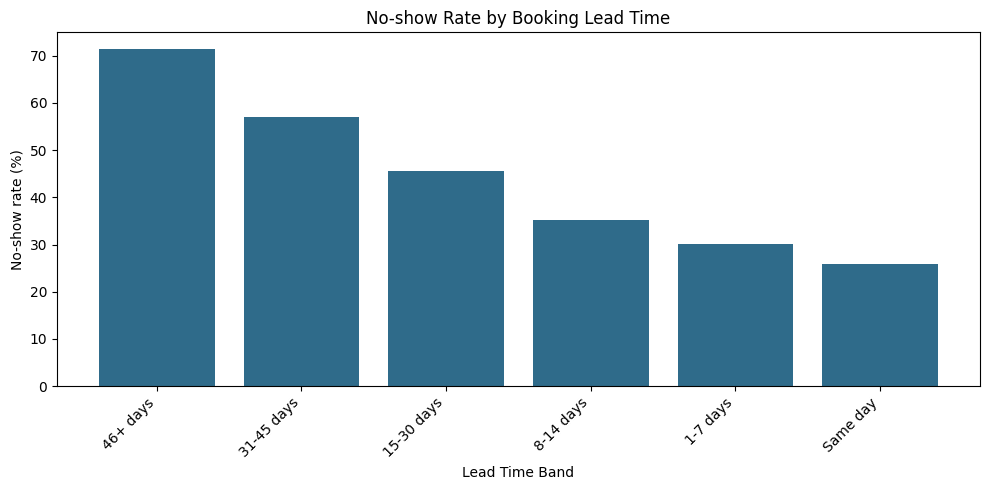

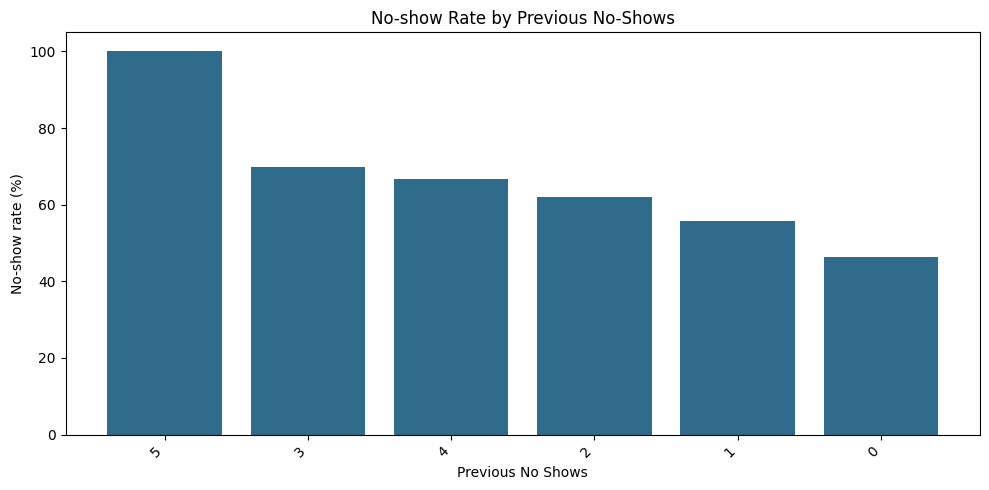

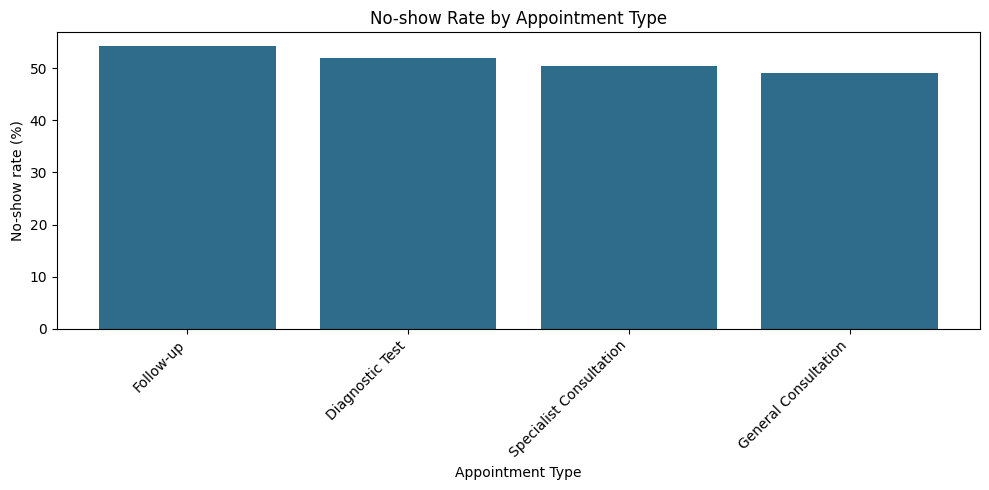

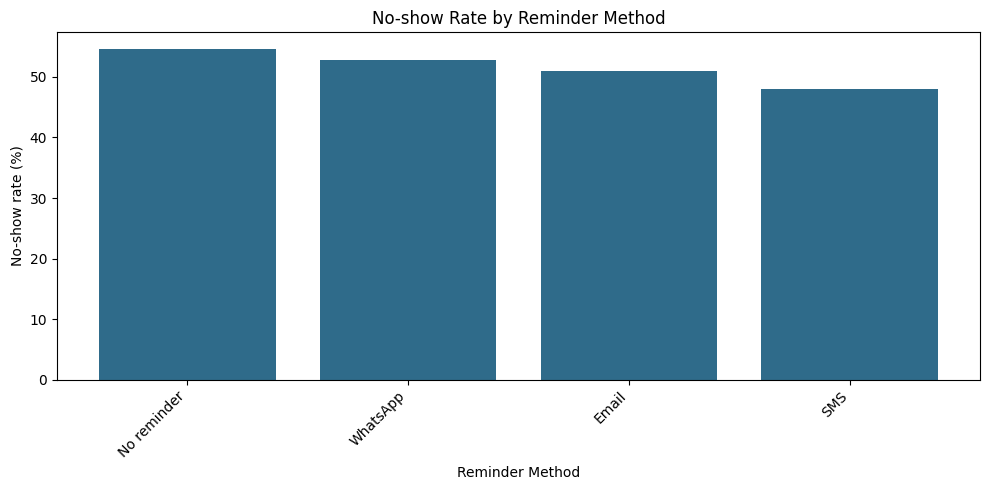

In [86]:
def plot_no_show_rate(data, group_column, title):
    table = no_show_rate_table(data, group_column)

    plot_data = table.dropna(subset=[group_column]).copy()

    plt.figure(figsize=(10, 5))
    plt.bar(
        plot_data[group_column].astype(str),
        plot_data["no_show_rate"],
        color="#2F6B8A"
    )
    plt.title(title)
    plt.ylabel("No-show rate (%)")
    plt.xlabel(group_column.replace("_", " ").title())
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_no_show_rate(df, "lead_time_band", "No-show Rate by Booking Lead Time")
plot_no_show_rate(df, "previous_no_shows", "No-show Rate by Previous No-Shows")
plot_no_show_rate(df, "appointment_type", "No-show Rate by Appointment Type")
plot_no_show_rate(df, "reminder_method", "No-show Rate by Reminder Method")


Create the primary modelling dataset

In [87]:
cancelled = df[df["appointment_outcome"] == "Cancelled"].copy()
cancelled.to_csv(
    OUTPUT_DIR / "cancelled_appointments_for_separate_analysis.csv",
    index=False
)

model_df = df[
    df["appointment_outcome"].isin(["Attended", "No-Show"])
].copy()

model_df["no_show"] = (
    model_df["appointment_outcome"] == "No-Show"
).astype(int)

print("Primary modelling rows:", len(model_df))
print(model_df["no_show"].value_counts())
print(model_df["no_show"].value_counts(normalize=True).round(4))


Primary modelling rows: 4737
no_show
1    2423
0    2314
Name: count, dtype: int64
no_show
1    0.5115
0    0.4885
Name: proportion, dtype: float64


Select leakage-safe features

In [88]:
# waiting_time_minutes is intentionally excluded.
# reminder fields are included only for a pre-appointment model in which
# reminder information is already known at scoring time.

numeric_features = [
    "age",
    "booking_lead_days",
    "previous_appointments",
    "previous_no_shows",
    "previous_no_show_rate",
    "distance_to_clinic_km",
    "appointment_month",
    "appointment_weekend",
    "new_patient"
]

categorical_features = [
    "gender",
    "appointment_type",
    "appointment_day",
    "appointment_time",
    "reminder_method"
]

feature_columns = numeric_features + categorical_features

X = model_df[feature_columns].copy()
y = model_df["no_show"].copy()
groups = model_df["patient_id"].copy()
dates = model_df["appointment_date"].copy()


Chronological split

In [89]:
valid_date_mask = dates.notna()

X_dated = X.loc[valid_date_mask].copy()
y_dated = y.loc[valid_date_mask].copy()
groups_dated = groups.loc[valid_date_mask].copy()
dates_dated = dates.loc[valid_date_mask].copy()

order = dates_dated.sort_values().index

X_sorted = X_dated.loc[order]
y_sorted = y_dated.loc[order]
groups_sorted = groups_dated.loc[order]
dates_sorted = dates_dated.loc[order]

cutoff_position = int(len(X_sorted) * 0.80)

X_train = X_sorted.iloc[:cutoff_position]
X_test = X_sorted.iloc[cutoff_position:]
y_train = y_sorted.iloc[:cutoff_position]
y_test = y_sorted.iloc[cutoff_position:]
groups_train = groups_sorted.iloc[:cutoff_position]
groups_test = groups_sorted.iloc[cutoff_position:]

print("Training date range:", dates_sorted.iloc[:cutoff_position].min(),
      "to", dates_sorted.iloc[:cutoff_position].max())
print("Test date range:", dates_sorted.iloc[cutoff_position:].min(),
      "to", dates_sorted.iloc[cutoff_position:].max())

patient_overlap = set(groups_train.dropna()) & set(groups_test.dropna())
print("Patient IDs overlapping across chronological split:", len(patient_overlap))

Training date range: 2025-01-01 00:00:00 to 2026-03-12 00:00:00
Test date range: 2026-03-13 00:00:00 to 2026-06-30 00:00:00
Patient IDs overlapping across chronological split: 657


Preprocessing pipeline

In [90]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

Baseline and candidate models

In [91]:
models = {
    "majority_baseline": DummyClassifier(
        strategy="most_frequent"
    ),
    "logistic_regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

fitted_models = {}
evaluation_rows = []

for name, estimator in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    pipeline.fit(X_train, y_train)
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)

    evaluation_rows.append({
        "model": name,
        "roc_auc": roc_auc_score(y_test, probabilities),
        "pr_auc": average_precision_score(y_test, probabilities),
        "brier_score": brier_score_loss(y_test, probabilities)
    })

    fitted_models[name] = pipeline

evaluation_table = pd.DataFrame(evaluation_rows).sort_values(
    "pr_auc",
    ascending=False
)

display(evaluation_table)
evaluation_table.to_csv(
    OUTPUT_DIR / "initial_model_comparison.csv",
    index=False
)

,model,roc_auc,pr_auc,brier_score
1,logistic_regression,0.675963,0.680236,0.226143
2,random_forest,0.664142,0.673412,0.229557
0,majority_baseline,0.500000,0.509494,0.490506


Detailed logistic-regression evaluation

              precision    recall  f1-score   support

           0      0.613     0.624     0.618       465
           1      0.632     0.621     0.626       483

    accuracy                          0.622       948
   macro avg      0.622     0.622     0.622       948
weighted avg      0.623     0.622     0.622       948



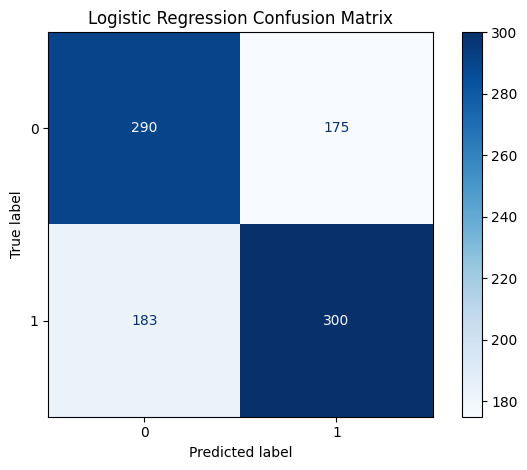

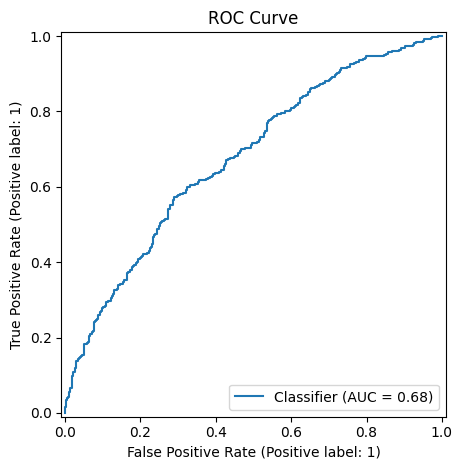

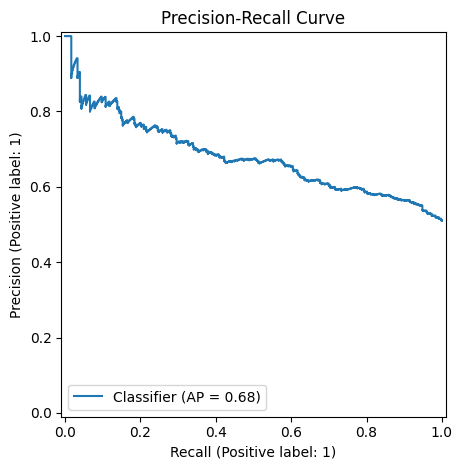

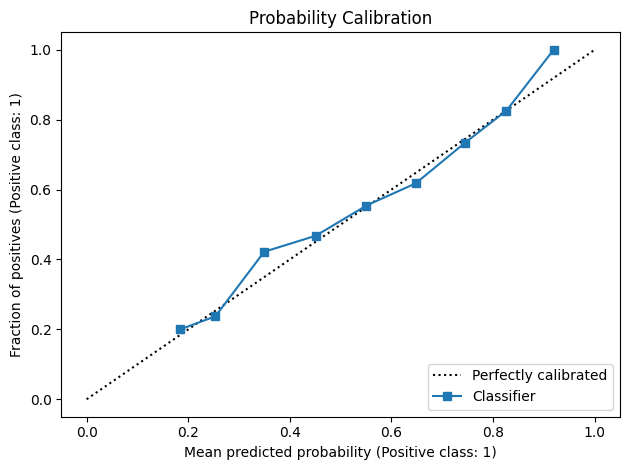

In [92]:
selected_model = fitted_models["logistic_regression"]

test_probabilities = selected_model.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= 0.5).astype(int)

print(classification_report(y_test, test_predictions, digits=3))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    cmap="Blues"
)
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, test_probabilities)
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, test_probabilities)
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

CalibrationDisplay.from_predictions(
    y_test,
    test_probabilities,
    n_bins=10
)
plt.title("Probability Calibration")
plt.tight_layout()
plt.show()

Threshold analysis

In [93]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    test_probabilities
)

threshold_table = pd.DataFrame({
    "threshold": np.append(thresholds, 1.0),
    "precision": precision,
    "recall": recall
})

threshold_table["f1"] = (
    2
    * threshold_table["precision"]
    * threshold_table["recall"]
    / (
        threshold_table["precision"]
        + threshold_table["recall"]
        + 1e-12
    )
)

best_f1_row = threshold_table.loc[
    threshold_table["f1"].idxmax()
]

display(best_f1_row.to_frame("value"))
threshold_table.to_csv(
    OUTPUT_DIR / "threshold_analysis.csv",
    index=False
)


,value
threshold,0.318939
precision,0.564496
recall,0.915114
f1,0.698262


Operational top-risk evaluation

In [94]:
ranking = pd.DataFrame({
    "actual_no_show": y_test.values,
    "predicted_probability": test_probabilities
}).sort_values("predicted_probability", ascending=False)

for top_fraction in [0.05, 0.10, 0.20, 0.30]:
    n_flagged = max(1, int(len(ranking) * top_fraction))
    flagged = ranking.head(n_flagged)

    precision_at_k = flagged["actual_no_show"].mean()
    recall_at_k = (
        flagged["actual_no_show"].sum()
        / ranking["actual_no_show"].sum()
    )

    print(
        f"Top {top_fraction:.0%}: "
        f"flagged={n_flagged}, "
        f"precision={precision_at_k:.3f}, "
        f"recall={recall_at_k:.3f}"
    )

Top 5%: flagged=47, precision=0.809, recall=0.079
Top 10%: flagged=94, precision=0.777, recall=0.151
Top 20%: flagged=189, precision=0.735, recall=0.288
Top 30%: flagged=284, precision=0.683, recall=0.402


Grouped cross-validation

In [95]:
eligible_group_mask = groups.notna()

X_grouped = X.loc[eligible_group_mask]
y_grouped = y.loc[eligible_group_mask]
groups_grouped = groups.loc[eligible_group_mask]

group_cv = GroupKFold(n_splits=5)

grouped_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

grouped_scores = cross_validate(
    grouped_pipeline,
    X_grouped,
    y_grouped,
    groups=groups_grouped,
    cv=group_cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision",
        "recall": "recall",
        "precision": "precision"
    },
    return_train_score=False
)

grouped_summary = pd.DataFrame(grouped_scores).agg(
    ["mean", "std"]
).T

display(grouped_summary)
grouped_summary.to_csv(
    OUTPUT_DIR / "grouped_cross_validation.csv"
)

,mean,std
fit_time,0.060565,0.001263
score_time,0.045184,0.001856
test_roc_auc,0.683186,0.017881
test_pr_auc,0.682211,0.018802
test_recall,0.624213,0.052736
test_precision,0.641280,0.016233


Permutation importance

In [96]:
importance = permutation_importance(
    selected_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_table = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std
}).sort_values("importance_mean", ascending=False)

display(importance_table)
importance_table.to_csv(
    OUTPUT_DIR / "permutation_importance.csv",
    index=False
)


,feature,importance_mean,importance_std
1,booking_lead_days,0.127315,0.014726
3,previous_no_shows,0.062390,0.007953
5,distance_to_clinic_km,0.007088,0.005455
4,previous_no_show_rate,0.004901,0.003515
10,appointment_type,0.004830,0.002269
2,previous_appointments,0.002480,0.002060
13,reminder_method,0.001789,0.003334
0,age,0.001449,0.000400
9,gender,0.000474,0.000695
7,appointment_weekend,0.000064,0.000219


Fairness and subgroup evaluation

In [97]:
evaluation_frame = model_df.loc[X_test.index, [
    "appointment_id",
    "gender",
    "age_group",
    "appointment_type",
    "reminder_method"
]].copy()

evaluation_frame["actual"] = y_test
evaluation_frame["probability"] = test_probabilities
evaluation_frame["prediction"] = test_predictions

def subgroup_metrics(data, group_column):
    rows = []

    for group_value, subset in data.groupby(
        group_column,
        dropna=False
    ):
        if len(subset) < 20:
            continue

        true_positive = (
            (subset["actual"] == 1)
            & (subset["prediction"] == 1)
        ).sum()

        false_negative = (
            (subset["actual"] == 1)
            & (subset["prediction"] == 0)
        ).sum()

        false_positive = (
            (subset["actual"] == 0)
            & (subset["prediction"] == 1)
        ).sum()

        true_negative = (
            (subset["actual"] == 0)
            & (subset["prediction"] == 0)
        ).sum()

        recall = true_positive / max(true_positive + false_negative, 1)
        precision = true_positive / max(true_positive + false_positive, 1)
        false_positive_rate = false_positive / max(
            false_positive + true_negative, 1
        )

        rows.append({
            group_column: group_value,
            "records": len(subset),
            "observed_no_show_rate": subset["actual"].mean(),
            "mean_predicted_risk": subset["probability"].mean(),
            "recall": recall,
            "precision": precision,
            "false_positive_rate": false_positive_rate
        })

    return pd.DataFrame(rows)

for column in [
    "gender",
    "age_group",
    "appointment_type",
    "reminder_method"
]:
    table = subgroup_metrics(evaluation_frame, column)
    print(f"\nSubgroup metrics by {column}")
    display(table)
    table.to_csv(
        OUTPUT_DIR / f"subgroup_metrics_{column}.csv",
        index=False
    )



Subgroup metrics by gender


,gender,records,observed_no_show_rate,mean_predicted_risk,recall,precision,false_positive_rate
0,Female,485,0.513402,0.504214,0.606426,0.611336,0.406780
1,Male,443,0.514673,0.498828,0.631579,0.660550,0.344186
2,Prefer not to say,20,0.300000,0.494967,0.833333,0.500000,0.357143



Subgroup metrics by age_group


,age_group,records,observed_no_show_rate,mean_predicted_risk,recall,precision,false_positive_rate
0,18-24,113,0.566372,0.502878,0.625000,0.714286,0.326531
1,25-34,140,0.500000,0.488645,0.657143,0.676471,0.314286
2,35-44,154,0.532468,0.496048,0.646341,0.670886,0.361111
3,45-54,135,0.540741,0.522920,0.616438,0.616438,0.451613
4,55-64,163,0.564417,0.509640,0.619565,0.670588,0.394366
5,65+,243,0.419753,0.494367,0.578431,0.517544,0.390071



Subgroup metrics by appointment_type


,appointment_type,records,observed_no_show_rate,mean_predicted_risk,recall,precision,false_positive_rate
0,Diagnostic Test,122,0.549180,0.486362,0.522388,0.625000,0.381818
1,Follow-up,267,0.606742,0.534501,0.697531,0.753333,0.352381
2,General Consultation,392,0.459184,0.484490,0.588889,0.576087,0.367925
3,Specialist Consultation,167,0.443114,0.499734,0.621622,0.541176,0.419355



Subgroup metrics by reminder_method


,reminder_method,records,observed_no_show_rate,mean_predicted_risk,recall,precision,false_positive_rate
0,Email,111,0.522523,0.515106,0.672414,0.650000,0.396226
1,No reminder,257,0.529183,0.551412,0.735294,0.628931,0.487603
2,SMS,360,0.500000,0.451637,0.522222,0.676259,0.250000
3,WhatsApp,220,0.495455,0.517929,0.614679,0.572650,0.450450


Save a cleaned analytical copy

In [98]:
# This is a separate file. The original resource remains unchanged.
df.to_csv(
    OUTPUT_DIR / "HealthConnect_Appointment_Data_cleaned.csv",
    index=False
)

model_df.to_csv(
    OUTPUT_DIR / "HealthConnect_NoShow_Modelling_Data.csv",
    index=False
)

print("Output files saved to:", OUTPUT_DIR.resolve())


Output files saved to: /content/outputs
